In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


In [4]:
# Load clean dataset
df = pd.read_csv('hotel_bookings_clean.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (86639, 42)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,arrival_date_month_num,arrival_date,total_nights,total_guests,total_revenue,season,lead_time_bucket,traveler_type,has_special_requests,includes_weekend
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,7,2015-07-01,1,1,75.0,Summer,Last-minute (1-7d),Leisure,0,0
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,7,2015-07-01,1,1,75.0,Summer,Short (8-30d),Corporate,0,0
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,196.0,Summer,Short (8-30d),Leisure,1,0
3,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,214.0,Summer,Same-day,Leisure,0,0
4,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,7,2015-07-01,2,2,206.0,Summer,Short (8-30d),Leisure,1,0


In [5]:
# Select features for modeling
features = [
    'lead_time', 'adr', 'total_nights', 'total_guests',
    'total_revenue', 'booking_changes', 'previous_cancellations',
    'previous_bookings_not_canceled', 'required_car_parking_spaces',
    'total_of_special_requests', 'has_special_requests',
    'includes_weekend', 'days_in_waiting_list',
    'hotel', 'deposit_type', 'customer_type', 'market_segment', 'meal'
]

target = 'is_canceled'

df_model = df[features + [target]].copy()
print(f'Modeling dataset shape: {df_model.shape}')

Modeling dataset shape: (86639, 19)


In [6]:
# Encode categorical columns
cat_cols = ['hotel', 'deposit_type', 'customer_type', 'market_segment', 'meal']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('Encoding done.')
df_model.head()

Encoding done.


,lead_time,adr,total_nights,total_guests,total_revenue,booking_changes,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,has_special_requests,includes_weekend,days_in_waiting_list,hotel,deposit_type,customer_type,market_segment,meal,is_canceled
0,7,75.0,1,1,75.0,0,0,0,0,0,0,0,0,1,0,2,3,0,0
1,13,75.0,1,1,75.0,0,0,0,0,0,0,0,0,1,0,2,2,0,0
2,14,98.0,2,2,196.0,0,0,0,0,1,1,0,0,1,0,2,6,0,0
3,0,107.0,2,2,214.0,0,0,0,0,0,0,0,0,1,0,2,3,0,0
4,9,103.0,2,2,206.0,0,0,0,0,1,1,0,0,1,0,2,3,1,0


In [7]:
# Split into features (X) and target (y)
X = df_model[features]
y = df_model[target]

# 80% train, 20% test — random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]:,}')
print(f'Test size:  {X_test.shape[0]:,}')
print(f'Cancellation rate in train: {y_train.mean()*100:.1f}%')
print(f'Cancellation rate in test:  {y_test.mean()*100:.1f}%')

Train size: 69,311
Test size:  17,328
Cancellation rate in train: 27.7%
Cancellation rate in test:  27.7%


In [8]:
# ── MODEL 1: Logistic Regression ──────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression Results:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'  Precision: {precision_score(y_test, y_pred_lr)*100:.2f}%')
print(f'  Recall:    {recall_score(y_test, y_pred_lr)*100:.2f}%')
print(f'  F1 Score:  {f1_score(y_test, y_pred_lr)*100:.2f}%')
print(f'  ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')

Logistic Regression Results:
  Accuracy:  77.18%
  Precision: 69.95%
  Recall:    30.81%
  F1 Score:  42.78%
  ROC-AUC:   0.7636


In [9]:
# ── MODEL 2: Decision Tree ────────────────────────────────
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Decision Tree Results:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_dt)*100:.2f}%')
print(f'  Precision: {precision_score(y_test, y_pred_dt)*100:.2f}%')
print(f'  Recall:    {recall_score(y_test, y_pred_dt)*100:.2f}%')
print(f'  F1 Score:  {f1_score(y_test, y_pred_dt)*100:.2f}%')
print(f'  ROC-AUC:   {roc_auc_score(y_test, y_prob_dt):.4f}')

Decision Tree Results:
  Accuracy:  79.11%
  Precision: 71.38%
  Recall:    40.96%
  F1 Score:  52.05%
  ROC-AUC:   0.7990


In [10]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt)],
    'Recall':    [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt)],
    'F1 Score':  [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_dt)]
})
results.set_index('Model', inplace=True)
results.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7718,0.6995,0.3081,0.4278,0.7636
Decision Tree,0.7911,0.7138,0.4096,0.5205,0.7990


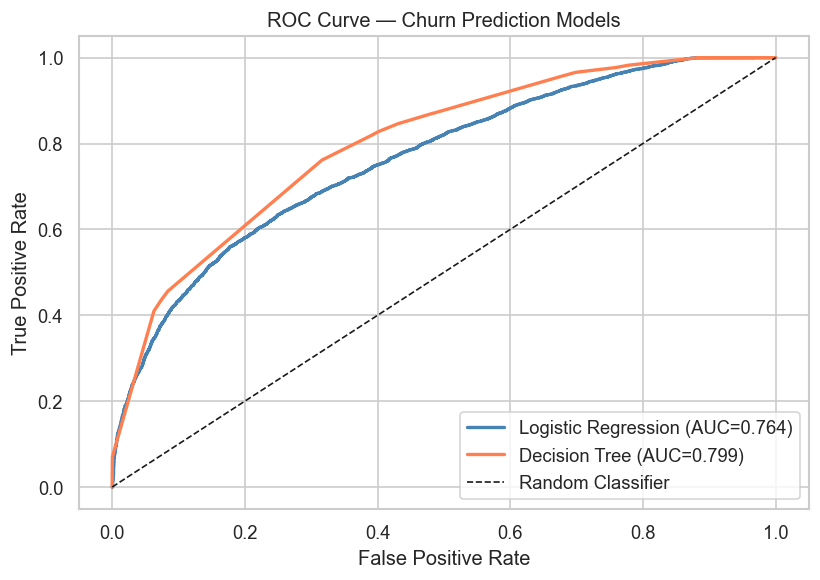

In [12]:
# ROC Curve — both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', color='steelblue', lw=2)
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_auc_score(y_test, y_prob_dt):.3f})', color='coral', lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_title('ROC Curve — Churn Prediction Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('01_roc_curve.png', bbox_inches='tight')
plt.show()

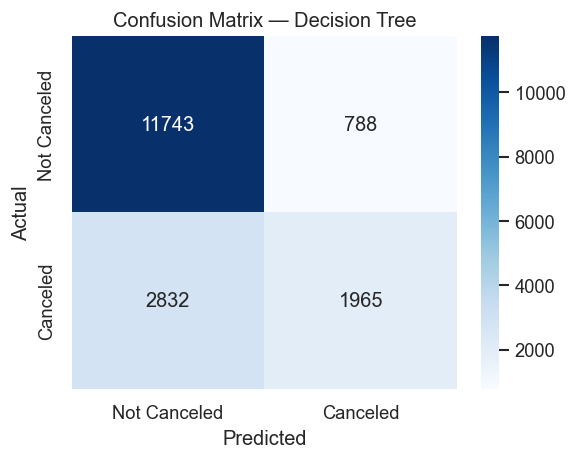

In [13]:
# Confusion Matrix — Decision Tree (better model)
cm = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Canceled','Canceled'],
            yticklabels=['Not Canceled','Canceled'])
ax.set_title('Confusion Matrix — Decision Tree')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('02_confusion_matrix.png', bbox_inches='tight')
plt.show()

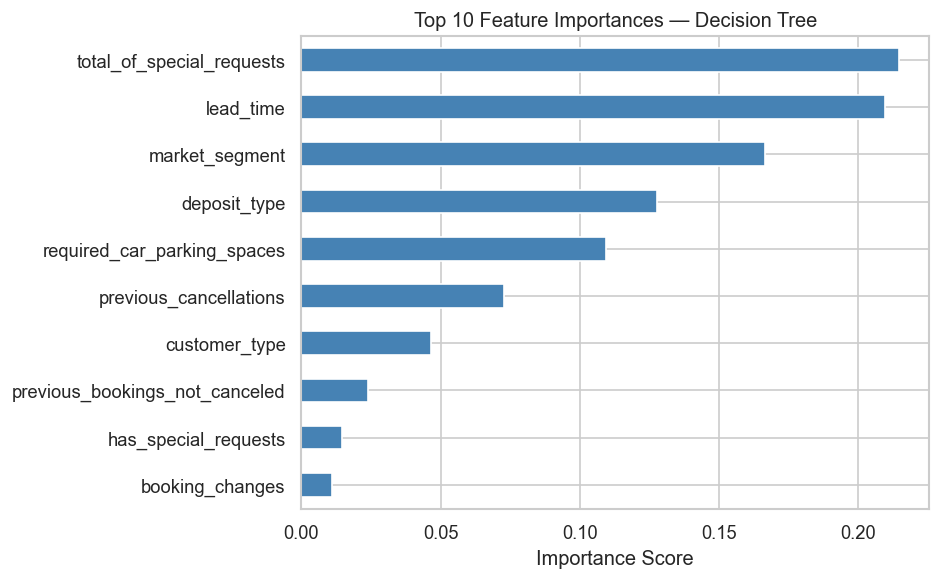

In [14]:
# Feature Importance — Decision Tree
feat_imp = pd.Series(dt.feature_importances_, index=features)
feat_imp = feat_imp.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Feature Importances — Decision Tree')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('03_feature_importance.png', bbox_inches='tight')
plt.show()

In [15]:
# Classification Report
print('Classification Report — Decision Tree:')
print(classification_report(y_test, y_pred_dt, target_names=['Not Canceled', 'Canceled']))

Classification Report — Decision Tree:
              precision    recall  f1-score   support

Not Canceled       0.81      0.94      0.87     12531
    Canceled       0.71      0.41      0.52      4797

    accuracy                           0.79     17328
   macro avg       0.76      0.67      0.69     17328
weighted avg       0.78      0.79      0.77     17328

